#随机森林超参数调优

┌─────────────────────────────────────────────────────────────┐
│                   随机森林参数体系                           
├─────────────────────────────────────────────────────────────┤
│                                                             
│  【第一层：树的数量】                                         
│   n_estimators  控制有多少棵树                               
│   ├─ 默认: 100                                              
│   ├─ 建议: 100-500（性价比最高）                             
│   └─ 规律: 越多越好，但收益递减                              
│                                                             
│  【第二层：树的复杂度】                                       
│   max_depth  单棵树的最大深度                                
│   ├─ 默认: None（不限制）                                   
│   ├─ 建议: 10-30                                            
│   └─ 规律: 太深→过拟合，太浅→欠拟合                          
│                                                             
│   min_samples_split  分裂所需最小样本数                       
│   ├─ 默认: 2                                                
│   ├─ 建议: 2-20                                             
│   └─ 规律: 越大→树越简单→欠拟合                              
│                                                             
│   min_samples_leaf  叶子节点最小样本数                        
│   ├─ 默认: 1                                                
│   ├─ 建议: 1-10                                             
│   └─ 规律: 越大→叶子越"粗糙"→欠拟合                          
│                                                             
│  【第三层：随机性控制】                                       
│   max_features  每次分裂考虑的特征数                          
│   ├─ 默认: 'sqrt'（回归）, 'log2'（分类）                    
│   ├─ 选项: 'sqrt', 'log2', 0.3-0.8, None                   
│   └─ 规律: 越少→树差异大→泛化强，越多→树相似→欠拟合           
│                                                             
│   bootstrap  是否使用 Bagging                                
│   ├─ 默认: True                                             
│   ├─ 建议: 保持 True                                        
│   └─ 说明: False=所有树用相同数据（失去随机性）               
│                                                             
│  【第四层：性能优化】                                         
│   n_jobs  并行计算的 CPU 核心数                             
│   ├─ 默认: None（单核）                                     
│   ├─ 建议: -1（使用全部核心）                               
│   └─ 效果: 训练速度提升 2-8 倍                               
│                                                             
│   random_state  随机种子                                    
│   ├─ 默认: None                                             
│   ├─ 建议: 42（或任意固定值）                                
│   └─ 作用: 保证结果可复现                                    
│                                                             
│  【第五层：高级选项】                                         
│   oob_score  是否计算袋外分数                                
│   ├─ 默认: False                                            
│   ├─ 建议: True（可以替代交叉验证）                           
│   └─ 原理: 用未被抽到的样本做验证                             
│                                                            
│   warm_start  是否热启动（增量训练）                          
│   ├─ 默认: False                                            
│   ├─ 用途: 先训练 100 棵树，再增加到 200 棵                   
│   └─ 场景: 不确定需要多少棵树时                              
└─────────────────────────────────────────────────────────────┘

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import time
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据准备完成")
print(f"特征数: {X.shape[1]}")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

数据准备完成
特征数: 135
训练集: 3811 样本
测试集: 953 样本


In [2]:
print("\n" + "="*70)
print("实验 1：树的数量对性能的影响")
print("="*70)

# 测试不同的树数量
n_trees_list = [10, 20, 50, 100, 150, 200, 300, 400, 500]
train_scores = []
test_scores = []
oob_scores = []
train_times = []

for n in n_trees_list:
    print(f"\n训练 {n} 棵树...")
    
    rf = RandomForestRegressor(
        n_estimators=n,
        oob_score=True,  # 计算 OOB 分数
        random_state=42,
        n_jobs=-1
    )
    
    # 训练并计时
    start = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - start
    
    # 评估
    train_r2 = rf.score(X_train, y_train)
    test_r2 = rf.score(X_test, y_test)
    oob_r2 = rf.oob_score_
    
    train_scores.append(train_r2)
    test_scores.append(test_r2)
    oob_scores.append(oob_r2)
    train_times.append(train_time)
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  OOB R²:   {oob_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  训练时间: {train_time:.2f}s")

# 找到性能最好和性价比最高的点
best_idx = np.argmax(test_scores)
best_n = n_trees_list[best_idx]

# 找到"收益递减点"（增加树后提升 < 0.001）
for i in range(1, len(test_scores)):
    if test_scores[i] - test_scores[i-1] < 0.001:
        optimal_idx = i
        optimal_n = n_trees_list[i]
        break
else:
    optimal_idx = best_idx
    optimal_n = best_n

print(f"\n" + "="*70)
print(f"最佳树数量: {best_n} (测试R²={test_scores[best_idx]:.4f})")
print(f"性价比最高: {optimal_n} (测试R²={test_scores[optimal_idx]:.4f}, "
      f"仅比最佳低 {test_scores[best_idx]-test_scores[optimal_idx]:.4f})")
print("="*70)


实验 1：树的数量对性能的影响

训练 10 棵树...
  训练集 R²: 0.9278
  OOB R²:   0.2678
  测试集 R²: 0.6660
  训练时间: 0.30s

训练 20 棵树...
  训练集 R²: 0.9400
  OOB R²:   0.5263
  测试集 R²: 0.6775
  训练时间: 0.58s

训练 50 棵树...
  训练集 R²: 0.9453
  OOB R²:   0.5495
  测试集 R²: 0.6882
  训练时间: 1.26s

训练 100 棵树...
  训练集 R²: 0.9402
  OOB R²:   0.5503
  测试集 R²: 0.6950
  训练时间: 2.80s

训练 150 棵树...
  训练集 R²: 0.9394
  OOB R²:   0.5564
  测试集 R²: 0.6958
  训练时间: 4.27s

训练 200 棵树...
  训练集 R²: 0.9399
  OOB R²:   0.5588
  测试集 R²: 0.6979
  训练时间: 5.24s

训练 300 棵树...
  训练集 R²: 0.9395
  OOB R²:   0.5614
  测试集 R²: 0.6982
  训练时间: 7.93s

训练 400 棵树...
  训练集 R²: 0.9395
  OOB R²:   0.5625
  测试集 R²: 0.6964
  训练时间: 10.20s

训练 500 棵树...
  训练集 R²: 0.9397
  OOB R²:   0.5630
  测试集 R²: 0.6969
  训练时间: 11.01s

最佳树数量: 300 (测试R²=0.6982)
性价比最高: 150 (测试R²=0.6958, 仅比最佳低 0.0024)


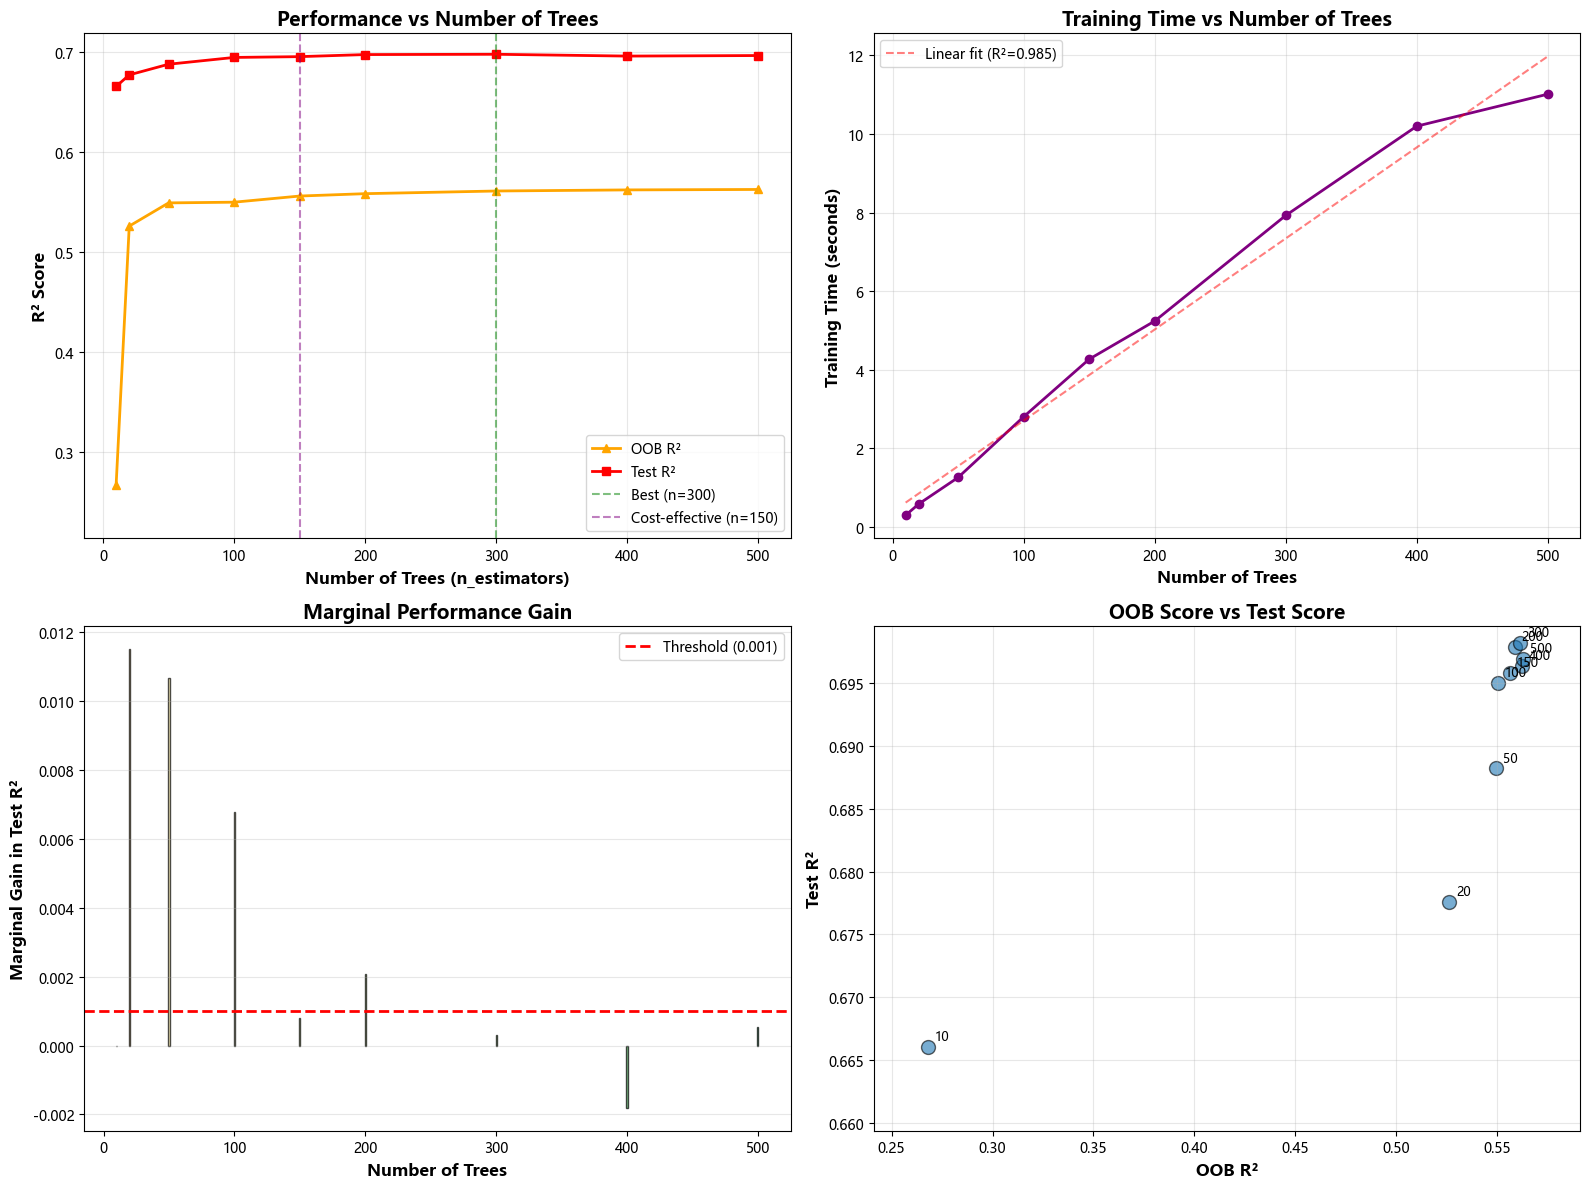


Image saved to ../figures/day09_n_estimators_analysis.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图 1：R² vs 树数量（去掉训练R²，太高会淹没其他曲线）
ax1 = axes[0, 0]
ax1.plot(n_trees_list, oob_scores, marker='^', linewidth=2, 
         label='OOB R²', color='orange')
ax1.plot(n_trees_list, test_scores, marker='s', linewidth=2, 
         label='Test R²', color='red')

# 标注最佳点和性价比点
ax1.axvline(best_n, color='green', linestyle='--', alpha=0.5, 
            label=f'Best (n={best_n})')
ax1.axvline(optimal_n, color='purple', linestyle='--', alpha=0.5, 
            label=f'Cost-effective (n={optimal_n})')

ax1.set_xlabel('Number of Trees (n_estimators)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs Number of Trees', fontsize=14, fontweight='bold')
ax1.set_ylim([min(oob_scores) * 0.8, max(test_scores) * 1.03])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 子图 2：训练时间 vs 树数量
ax2 = axes[0, 1]
ax2.plot(n_trees_list, train_times, marker='o', linewidth=2, color='purple')
ax2.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax2.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Training Time vs Number of Trees', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 添加线性拟合
from scipy.stats import linregress
slope, intercept, r_val, p_val, std_err = linregress(n_trees_list, train_times)
ax2.plot(n_trees_list, [slope*n + intercept for n in n_trees_list], 
         'r--', alpha=0.5, label=f'Linear fit (R²={r_val**2:.3f})')
ax2.legend()

# 子图 3：性能提升曲线（边际收益）
ax3 = axes[1, 0]
marginal_gains = [0] + [test_scores[i] - test_scores[i-1] for i in range(1, len(test_scores))]
ax3.bar(n_trees_list, marginal_gains, color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(marginal_gains))),
        edgecolor='black', alpha=0.7)
ax3.axhline(0.001, color='red', linestyle='--', linewidth=2, 
            label='Threshold (0.001)')
ax3.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax3.set_ylabel('Marginal Gain in Test R²', fontsize=12, fontweight='bold')
ax3.set_title('Marginal Performance Gain', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 子图 4：OOB vs 测试集对比（各自独立缩放，不强制等比例）
ax4 = axes[1, 1]
ax4.scatter(oob_scores, test_scores, s=100, alpha=0.6, edgecolors='k')
ax4.set_xlim([min(oob_scores) * 0.9, max(oob_scores) * 1.05])
ax4.set_ylim([min(test_scores) * 0.99, max(test_scores) * 1.002])

# 标注每个点的树数量
for i, n in enumerate(n_trees_list):
    ax4.annotate(f'{n}', xy=(oob_scores[i], test_scores[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

ax4.set_xlabel('OOB R²', fontsize=12, fontweight='bold')
ax4.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax4.set_title('OOB Score vs Test Score', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day09_n_estimators_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nImage saved to ../figures/day09_n_estimators_analysis.png")

In [4]:
print("\n" + "="*70)
print("实验 2：特征随机性对性能的影响")
print("="*70)

# 测试不同的 max_features
max_features_list = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0]
max_features_results = []

# 用刚才找到的最优树数量
optimal_n_estimators = optimal_n

for max_feat in max_features_list:
    print(f"\n测试 max_features={max_feat}...")
    
    rf = RandomForestRegressor(
        n_estimators=optimal_n_estimators,
        max_features=max_feat,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    train_r2 = rf.score(X_train, y_train)
    test_r2 = rf.score(X_test, y_test)
    oob_r2 = rf.oob_score_
    gap = train_r2 - test_r2
    
    # 计算实际使用的特征数
    if max_feat == 'sqrt':
        n_features_used = int(np.sqrt(X.shape[1]))
    elif max_feat == 'log2':
        n_features_used = int(np.log2(X.shape[1]))
    elif isinstance(max_feat, float):
        n_features_used = int(max_feat * X.shape[1])
    else:
        n_features_used = X.shape[1]
    
    max_features_results.append({
        'max_features': str(max_feat),
        'n_features_used': n_features_used,
        'train_r2': train_r2,
        'oob_r2': oob_r2,
        'test_r2': test_r2,
        'gap': gap
    })
    
    print(f"  实际使用特征数: {n_features_used}/{X.shape[1]}")
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  OOB R²:   {oob_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  过拟合程度: {gap:.4f}")

# 创建结果 DataFrame
max_features_df = pd.DataFrame(max_features_results)
max_features_df = max_features_df.sort_values('test_r2', ascending=False)

print(f"\n结果汇总（按测试R²排序）:\n")
print(max_features_df.to_string(index=False))


实验 2：特征随机性对性能的影响

测试 max_features=sqrt...
  实际使用特征数: 11/135
  训练集 R²: 0.9429
  OOB R²:   0.5792
  测试集 R²: 0.7069
  过拟合程度: 0.2360

测试 max_features=log2...
  实际使用特征数: 7/135
  训练集 R²: 0.9432
  OOB R²:   0.5813
  测试集 R²: 0.6983
  过拟合程度: 0.2449

测试 max_features=0.3...
  实际使用特征数: 40/135
  训练集 R²: 0.9422
  OOB R²:   0.5755
  测试集 R²: 0.7027
  过拟合程度: 0.2396

测试 max_features=0.5...
  实际使用特征数: 67/135
  训练集 R²: 0.9416
  OOB R²:   0.5707
  测试集 R²: 0.6941
  过拟合程度: 0.2475

测试 max_features=0.7...
  实际使用特征数: 94/135
  训练集 R²: 0.9410
  OOB R²:   0.5675
  测试集 R²: 0.7020
  过拟合程度: 0.2390

测试 max_features=1.0...
  实际使用特征数: 135/135
  训练集 R²: 0.9394
  OOB R²:   0.5564
  测试集 R²: 0.6958
  过拟合程度: 0.2436

结果汇总（按测试R²排序）:

max_features  n_features_used  train_r2   oob_r2  test_r2      gap
        sqrt               11  0.942873 0.579248 0.706907 0.235966
         0.3               40  0.942238 0.575480 0.702687 0.239552
         0.7               94  0.940967 0.567454 0.702008 0.238960
        log2                7

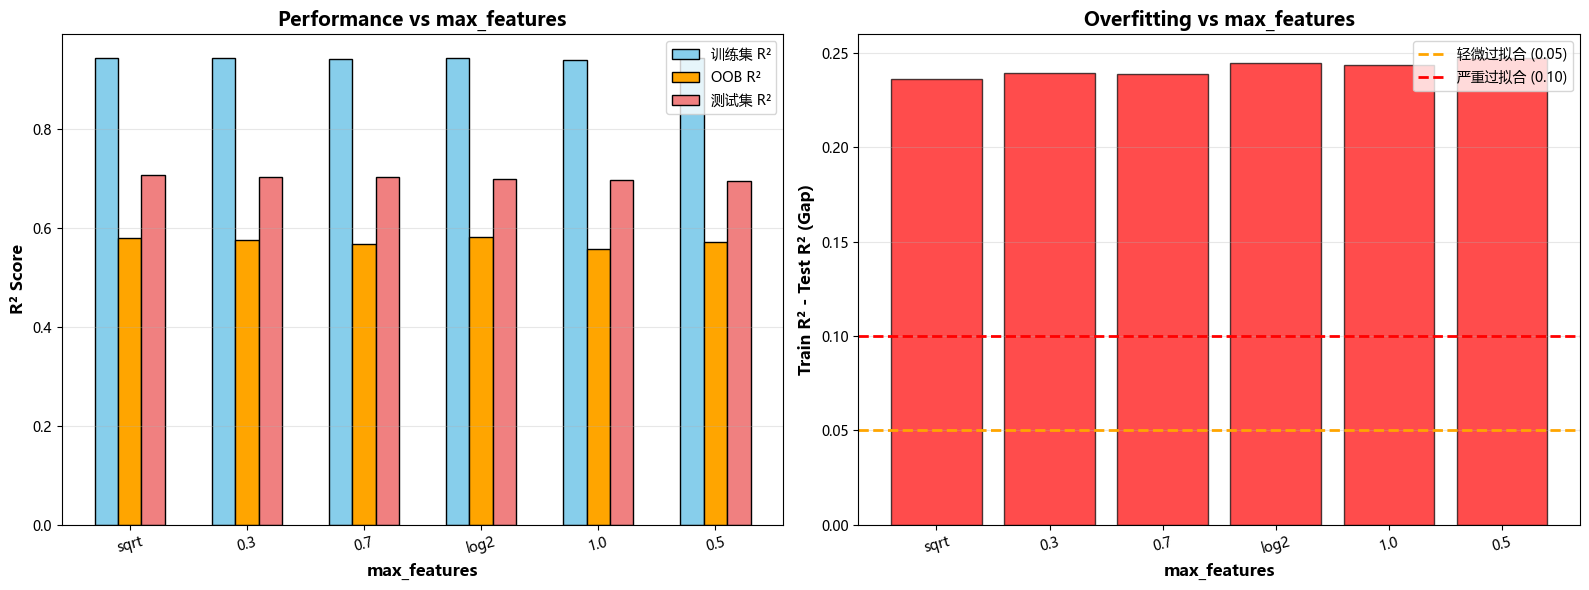


✓ 图片已保存到 ../figures/day09_max_features_analysis.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² vs max_features
ax1 = axes[0]
x_pos = np.arange(len(max_features_df))

bars1 = ax1.bar(x_pos - 0.2, max_features_df['train_r2'], 0.2, 
                label='训练集 R²', color='skyblue', edgecolor='black')
bars2 = ax1.bar(x_pos, max_features_df['oob_r2'], 0.2, 
                label='OOB R²', color='orange', edgecolor='black')
bars3 = ax1.bar(x_pos + 0.2, max_features_df['test_r2'], 0.2, 
                label='测试集 R²', color='lightcoral', edgecolor='black')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(max_features_df['max_features'], rotation=15)
ax1.set_xlabel('max_features', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs max_features', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 右图：过拟合程度 vs 特征数
ax2 = axes[1]
colors = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' 
          for g in max_features_df['gap']]

bars = ax2.bar(x_pos, max_features_df['gap'], color=colors, 
               alpha=0.7, edgecolor='black')
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=2, 
            label='轻微过拟合 (0.05)')
ax2.axhline(0.10, color='red', linestyle='--', linewidth=2, 
            label='严重过拟合 (0.10)')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(max_features_df['max_features'], rotation=15)
ax2.set_xlabel('max_features', fontsize=12, fontweight='bold')
ax2.set_ylabel('Train R² - Test R² (Gap)', fontsize=12, fontweight='bold')
ax2.set_title('Overfitting vs max_features', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/day09_max_features_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 图片已保存到 ../figures/day09_max_features_analysis.png")

In [6]:
print("\n" + "="*70)
print("网格搜索：寻找最佳参数组合（快版）")
print("="*70)

# 2×2×2×2 = 16 组合 × 3 折 = 48 个模型，约 2 分钟
param_grid = {
    'n_estimators': [optimal_n, 200],
    'max_depth': [15, None],
    'max_features': ['sqrt', 0.5],
    'min_samples_leaf': [3, 5]
}

n_combinations = 2 * 2 * 2 * 2
print(f"参数组合数: {n_combinations}")
print(f"交叉验证折数: 3")
print(f"总计训练模型数: {n_combinations * 3}")
print("预计 2~3 分钟")

# GridSearchCV 并行跑（n_jobs=-1），RF 内部不并行（n_jobs=1），避免嵌套
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=1),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

print("开始网格搜索...")
start_time = time.time()
grid_search.fit(X_train, y_train)
search_time = time.time() - start_time

print(f"\n网格搜索完成，耗时 {search_time:.0f} 秒")

print("\n" + "="*70)
print("网格搜索结果")
print("="*70)
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证 R²: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
test_r2_final = best_rf.score(X_test, y_test)
train_r2_final = best_rf.score(X_train, y_train)

print(f"\n最终模型性能:")
print(f"  训练集 R²: {train_r2_final:.4f}")
print(f"  测试集 R²: {test_r2_final:.4f}")
print(f"  过拟合程度: {train_r2_final - test_r2_final:.4f}")
print("="*70)


网格搜索：寻找最佳参数组合（快版）
参数组合数: 16
交叉验证折数: 3
总计训练模型数: 48
预计 2~3 分钟
开始网格搜索...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

网格搜索完成，耗时 39 秒

网格搜索结果
最佳参数: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 150}
最佳交叉验证 R²: 0.5905

最终模型性能:
  训练集 R²: 0.8255
  测试集 R²: 0.6972
  过拟合程度: 0.1283



Top 10 参数组合:

 param_n_estimators param_max_depth param_max_features  param_min_samples_leaf  mean_test_score  std_test_score
                150            None                0.5                       3         0.590498        0.027654
                200            None                0.5                       5         0.589270        0.030269
                200            None                0.5                       3         0.588676        0.028373
                200              15                0.5                       5         0.588157        0.031589
                150            None                0.5                       5         0.587555        0.029392
                150              15                0.5                       5         0.587136        0.030749
                150              15                0.5                       3         0.586821        0.027359
                200            None               sqrt                       3         0.

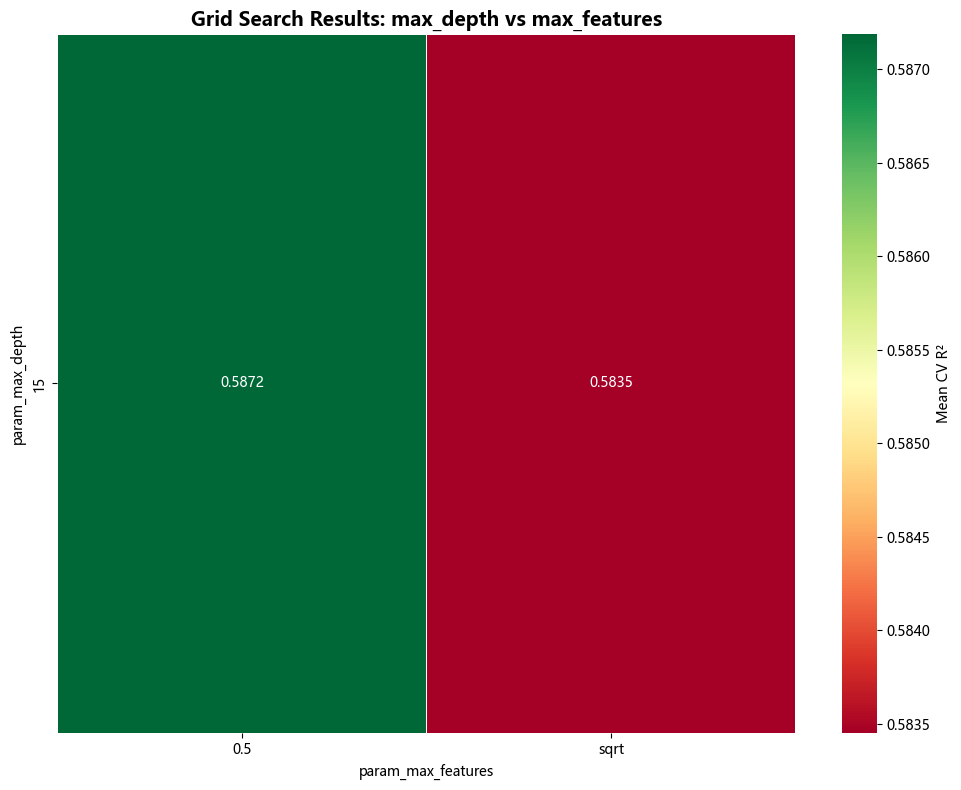

In [7]:
# 提取网格搜索的所有结果
results = pd.DataFrame(grid_search.cv_results_)

# 只看关键列
results_summary = results[[
    'param_n_estimators', 'param_max_depth', 'param_max_features', 
    'param_min_samples_leaf', 'mean_test_score', 'std_test_score'
]].copy()

# 按分数排序
results_summary = results_summary.sort_values('mean_test_score', ascending=False)

print("\nTop 10 参数组合:\n")
print(results_summary.head(10).to_string(index=False))

# 可视化：热力图（max_depth vs max_features）
if len(param_grid['max_depth']) > 1 and len(param_grid['max_features']) > 1:
    # 创建透视表
    pivot_data = results.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_max_features'
    )
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn', 
                cbar_kws={'label': 'Mean CV R²'}, linewidths=0.5)
    plt.title('Grid Search Results: max_depth vs max_features', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/day09_grid_search_heatmap.png', dpi=150)
    plt.show()

In [8]:
print("\n" + "="*70)
print("全流程模型对比")
print("="*70)

# 加载之前的模型
dt_best = joblib.load('../models/day03_best_tree.pkl')
rf_day8 = joblib.load('../models/day08_random_forest_default.pkl')

# 评估所有模型
models = {
    'Week 1: 决策树（最佳）': dt_best,
    'Day 8: 随机森林（默认）': rf_day8,
    'Day 9: 随机森林（调优）': best_rf
}

comparison_results = []

for name, model in models.items():
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    comparison_results.append({
        'Model': name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Gap': train_r2 - test_r2
    })

comparison_df = pd.DataFrame(comparison_results)

print("\n模型性能对比:\n")
print(comparison_df.to_string(index=False))

# 计算改进幅度
dt_test_r2 = comparison_df[comparison_df['Model'].str.contains('决策树')]['Test_R2'].values[0]
rf_day8_test_r2 = comparison_df[comparison_df['Model'].str.contains('Day 8')]['Test_R2'].values[0]
rf_day9_test_r2 = comparison_df[comparison_df['Model'].str.contains('Day 9')]['Test_R2'].values[0]

print(f"\n改进历程:")
print(f"  决策树 → 随机森林（默认）: +{rf_day8_test_r2 - dt_test_r2:.4f} ({(rf_day8_test_r2 - dt_test_r2)/dt_test_r2*100:+.2f}%)")
print(f"  随机森林（默认）→ 随机森林（调优）: +{rf_day9_test_r2 - rf_day8_test_r2:.4f} ({(rf_day9_test_r2 - rf_day8_test_r2)/rf_day8_test_r2*100:+.2f}%)")
print(f"  总提升（决策树 → 调优随机森林）: +{rf_day9_test_r2 - dt_test_r2:.4f} ({(rf_day9_test_r2 - dt_test_r2)/dt_test_r2*100:+.2f}%)")


全流程模型对比

模型性能对比:

          Model  Train_R2  Test_R2      Gap
Week 1: 决策树（最佳）  0.649914 0.578071 0.071844
Day 8: 随机森林（默认）  0.940199 0.695000 0.245199
Day 9: 随机森林（调优）  0.825464 0.697165 0.128299

改进历程:
  决策树 → 随机森林（默认）: +0.1169 (+20.23%)
  随机森林（默认）→ 随机森林（调优）: +0.0022 (+0.31%)
  总提升（决策树 → 调优随机森林）: +0.1191 (+20.60%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：R² 对比
ax1 = axes[0]
model_names = [m.split(':')[1].strip() for m in comparison_df['Model']]
x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['Train_R2'], width, 
                label='Train R²', color='skyblue', edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison_df['Test_R2'], width, 
                label='Test R²', color='lightcoral', edgecolor='black')

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1.05])

# 右图：改进历程（跳过基线，只画有提升的两个柱子）
ax2 = axes[1]
# 只取 Day 8 和 Day 9 的改进（去掉 Day 1 的 0 值基线）
improvements = [test_r2s[1] - test_r2s[0], test_r2s[2] - test_r2s[1]]
improve_labels = ['Day 8 (RF default)', 'Day 9 (RF tuned)']
x_imp = np.arange(len(improvements))

colors_improvement = ['green', 'green']
bars_imp = ax2.bar(x_imp, improvements, color=colors_improvement, alpha=0.7, edgecolor='black')

ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(x_imp)
ax2.set_xticklabels(improve_labels, rotation=15, ha='right')
ax2.set_ylabel('Improvement in Test R²', fontsize=12, fontweight='bold')
ax2.set_title('Performance Improvement History', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars_imp, improvements):
    ax2.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:+.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/day09_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal comparison saved to ../figures/day09_final_comparison.png")

In [10]:
# 保存调优后的随机森林
joblib.dump(best_rf, '../models/day09_random_forest_tuned.pkl')
print("\nTuned RF saved to ../models/day09_random_forest_tuned.pkl")

# 保存调参结果
import json

def to_python(val):
    """numpy 类型转 Python 原生，避免 json.dump 报错"""
    if isinstance(val, (int, np.integer)):
        return int(val)
    if isinstance(val, (float, np.floating)):
        return float(val)
    return str(val)

tuning_summary = {
    'best_params': {k: to_python(v) for k, v in grid_search.best_params_.items()},
    'best_cv_score': float(grid_search.best_score_),
    'test_r2': float(test_r2_final),
    'train_r2': float(train_r2_final),
    'overfitting_gap': float(train_r2_final - test_r2_final),
    'optimal_n_estimators_from_exp1': int(optimal_n),
    'grid_search_time_seconds': float(search_time),
    'improvements': {
        'from_decision_tree': float(rf_day9_test_r2 - dt_test_r2),
        'from_default_rf': float(rf_day9_test_r2 - rf_day8_test_r2)
    }
}

with open('../models/day09_tuning_results.json', 'w') as f:
    json.dump(tuning_summary, f, indent=2)

print("Tuning results saved to ../models/day09_tuning_results.json")

# 打印最终总结
print("\n" + "="*70)
print("Day 9 Final Summary")
print("="*70)
print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nPerformance:")
print(f"  CV R²:     {grid_search.best_score_:.4f}")
print(f"  Test R²:   {test_r2_final:.4f}")
print(f"  Overfit:   {train_r2_final - test_r2_final:.4f}")

print(f"\nKey findings:")
print(f"  1. Optimal n_estimators: {optimal_n} (experiment 1)")
print(f"  2. Best max_features: {grid_search.best_params_['max_features']} (experiment 2)")
print(f"  3. Max depth: {grid_search.best_params_['max_depth']}")
print(f"  4. Improvement over DT: {(rf_day9_test_r2 - dt_test_r2)/dt_test_r2*100:.2f}%")
print("="*70)


Tuned RF saved to ../models/day09_random_forest_tuned.pkl
Tuning results saved to ../models/day09_tuning_results.json

Day 9 Final Summary

Best parameters:
  max_depth: None
  max_features: 0.5
  min_samples_leaf: 3
  n_estimators: 150

Performance:
  CV R²:     0.5905
  Test R²:   0.6972
  Overfit:   0.1283

Key findings:
  1. Optimal n_estimators: 150 (experiment 1)
  2. Best max_features: 0.5 (experiment 2)
  3. Max depth: None
  4. Improvement over DT: 20.60%
